<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/13_Prophet_unsolved_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Time Series Forecasting with Facebook Prophet**

## Introduction
In this exercise, you will use **Facebook Prophet** to forecast Microsoft's closing stock price.

You will:
1. Load and preprocess the data into Prophet's required format
2. Initialize, configure, and fit a Prophet model
3. Generate future forecasts and visualise results
4. Evaluate forecast accuracy with Mean Absolute Error (MAE)

Fill in every `________` blank to complete the code.

**Dataset:** [Microsoft Stock — Time Series Analysis](https://www.kaggle.com/datasets/vijayvvenkitesh/microsoft-stock-time-series-analysis) — download `Microsoft_Stock.csv` and place it in the same directory as this notebook.

The dataset contains daily OHLCV data for Microsoft (MSFT) with columns: `Date`, `Open`, `High`, `Low`, `Close`, `Volume`.

In [39]:
# Install yfinance to get the data reliably
!pip install yfinance -q

import yfinance as yf
import pandas as pd

# Download Microsoft stock data
msft = yf.Ticker("MSFT")
df_raw = msft.history(period="5y")
df_raw.reset_index(inplace=True)
df_raw.to_csv('Microsoft_Stock.csv', index=False)
print("Dataset downloaded successfully via yfinance.")

Dataset downloaded successfully via yfinance.


## Step 1: Import Libraries

We need `pandas` for data handling, `matplotlib` for plotting, and `Prophet` for time series forecasting.

**Task:** Import `Prophet` from the correct module.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

## Step 2: Load and Preprocess the Dataset

Prophet requires a DataFrame with exactly two columns:
- `ds` — the datestamp column
- `y` — the target value to forecast

We will forecast the **closing price** of Microsoft stock.

**Hint:** The relevant columns in this dataset are `Date` and `Close`.

In [41]:
# Load the dataset we just created with yfinance
df = pd.read_csv('Microsoft_Stock.csv')

# Quick look at the columns to verify names
print("Columns found:", df.columns.tolist())
display(df.head())

Columns found: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-04-12 00:00:00-04:00,244.409414,247.249717,244.323043,245.560883,27148700,0.0,0.0
1,2021-04-13 00:00:00-04:00,246.856290,248.708233,246.443657,248.036530,23837500,0.0,0.0
2,2021-04-14 00:00:00-04:00,247.067396,248.362778,244.841211,245.253815,23070900,0.0,0.0
3,2021-04-15 00:00:00-04:00,247.499191,249.418310,247.307297,249.005707,25627500,0.0,0.0
4,2021-04-16 00:00:00-04:00,248.976957,250.445082,247.182585,250.195587,24878600,0.0,0.0


In [42]:
# Select the date column and the closing price column, then rename to 'ds' and 'y'
df = df[['Date', 'Close']].copy()
df.columns = ['ds', 'y']

# Ensure 'ds' is datetime type and timezone-naive as required by Prophet
df['ds'] = pd.to_datetime(df['ds'], utc=True).dt.tz_localize(None)

In [43]:
# Ensure 'ds' is datetime type
df['ds'] = pd.to_datetime(df['ds'])

# Sort by date
df = df.sort_values('ds').reset_index(drop=True)

print(f"Date range: {df['ds'].min()} to {df['ds'].max()}")
print(f"Number of data points: {len(df)}")

Date range: 2021-04-12 04:00:00 to 2026-04-10 04:00:00
Number of data points: 1256


In [44]:
# Check for missing values
print(df.isnull().sum())

# Drop missing values if any
df = df.dropna()

ds    0
y     0
dtype: int64


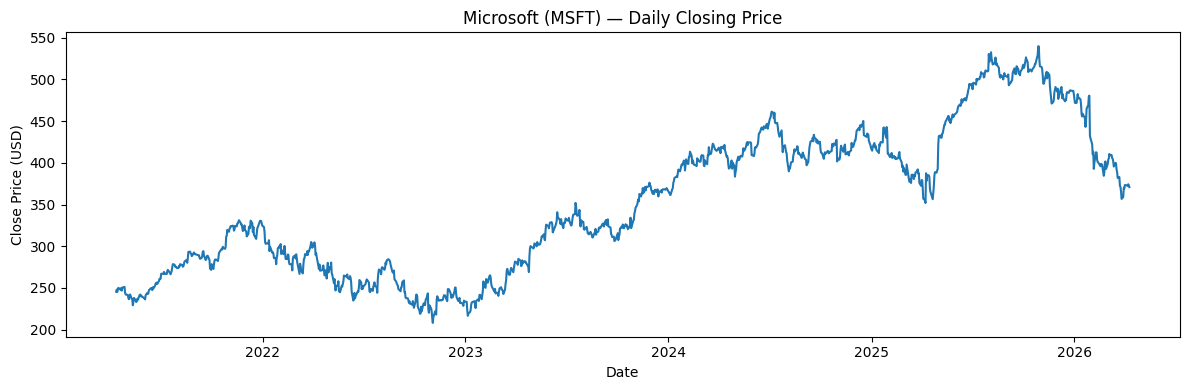

In [52]:
# Visualise the historical closing price
plt.figure(figsize=(12, 4))
plt.plot(df['ds'], df['y'])
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.title('Microsoft (MSFT) — Daily Closing Price')
plt.tight_layout()
plt.show()

## Step 3: Initialize and Fit the Prophet Model

Prophet accepts several configuration parameters. A common one is `yearly_seasonality`, which tells the model whether to fit a yearly seasonal component.

**Task:** Create a Prophet model with `yearly_seasonality` set to `True`, then fit it to the data.

In [46]:
# Initialize Prophet with yearly_seasonality enabled
model = Prophet(yearly_seasonality=True)

# Fit the model to the data
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## Step 4: Generate the Forecast

We create a dataframe of future dates and use the trained model to predict.

**Task:** Generate a future dataframe covering 90 days beyond the training data.

**Note:** Stock markets are closed on weekends. By default, `make_future_dataframe` generates
calendar days (including weekends). We can pass `freq='B'` to generate only **business days**.

In [47]:
# Create a future dataframe for 90 business days ahead
future = model.make_future_dataframe(periods=90, freq='B')

print(f"Future dataframe shape: {future.shape}")
display(future.tail())

Future dataframe shape: (1346, 1)


,ds
1341,2026-08-10 04:00:00
1342,2026-08-11 04:00:00
1343,2026-08-12 04:00:00
1344,2026-08-13 04:00:00
1345,2026-08-14 04:00:00


In [48]:
# Generate the forecast
forecast = model.predict(future)

# Inspect key forecast columns
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
1341,2026-08-10 04:00:00,491.511221,442.938787,538.386687
1342,2026-08-11 04:00:00,491.519887,442.763565,543.701442
1343,2026-08-12 04:00:00,491.881841,440.721124,541.183948
1344,2026-08-13 04:00:00,491.548110,439.910931,541.410425
1345,2026-08-14 04:00:00,491.915706,440.407484,542.941619


## Step 5: Visualise the Forecast and Components

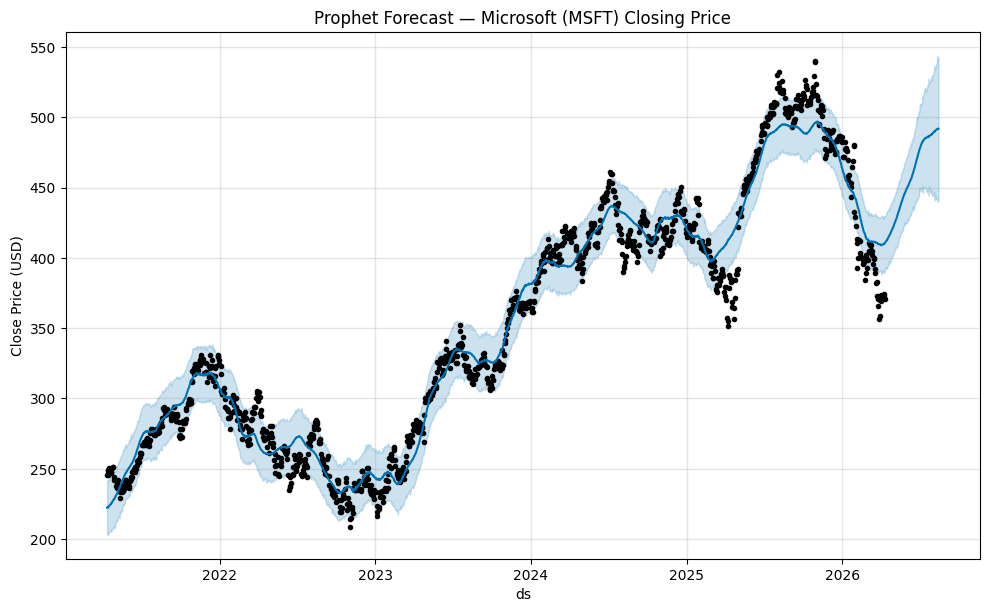

In [53]:
# Plot the forecast (black dots = actual, blue line = prediction, shaded = uncertainty)
fig = model.plot(forecast)
plt.title('Prophet Forecast — Microsoft (MSFT) Closing Price')
plt.ylabel('Close Price (USD)')
plt.show()

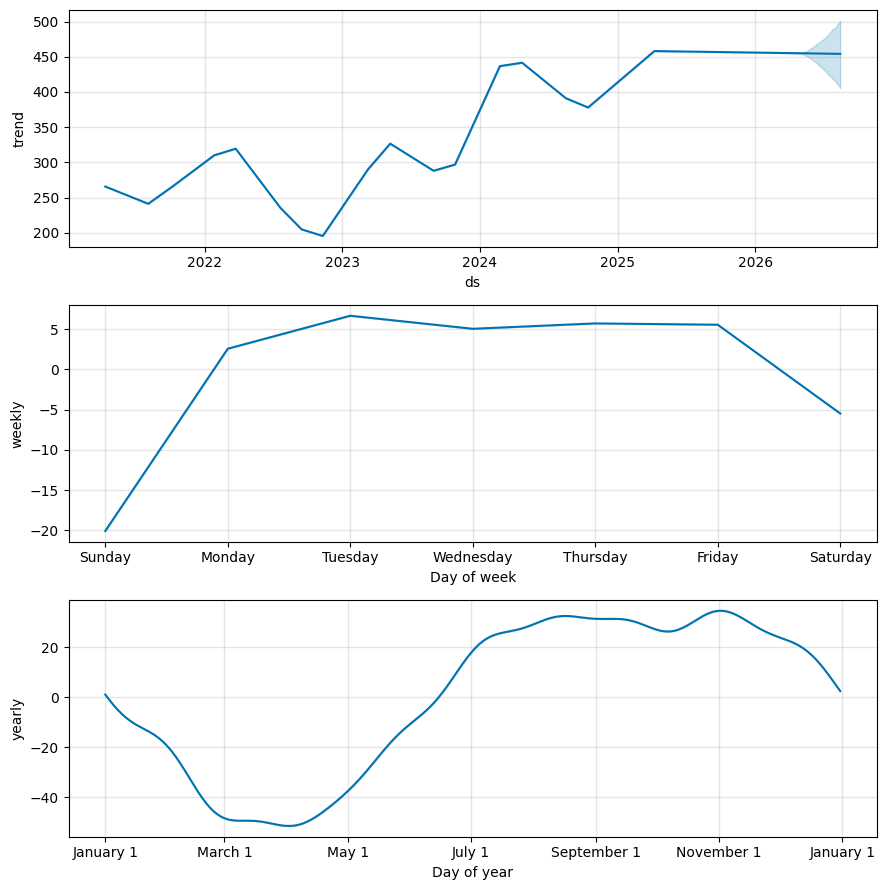

In [54]:
# Plot trend + seasonal components
fig2 = model.plot_components(forecast)
plt.show()

## Step 6: Evaluate Forecast Accuracy

We compute the **Mean Absolute Error (MAE)** on the historical (in-sample) predictions.

In [51]:
from sklearn.metrics import mean_absolute_error

# Merge actual and predicted values
df_forecast = forecast[['ds', 'yhat']].set_index('ds')
df_actual = df.set_index('ds')
df_combined = pd.merge(df_actual, df_forecast, left_index=True, right_index=True)

# Calculate Mean Absolute Error
mae = mean_absolute_error(df_combined['y'], df_combined['yhat'])
print(f'Mean Absolute Error: ${mae:,.2f}')

Mean Absolute Error: $11.83
